Ce fichier regroupe plusieurs méthodes de classification du mouvement : seuil AC > 0, seuil AC > 2, RandomForest, Clustering (kmeans). Chaque modèle prédit pour 1 sec un "mouvement" ou un "non mouvement", puis ces résultats sont comparés aux annotations disponnibles dans "C:/Users/roman/Documents/BEaCHILD/X_et_Y" (correspondent aux annotations RCT1 de CAP). Les modèles sont évalués par le score F1, le score d'accuracy et l'analyse de la matrice de confusion.

Les étapes réalisées sont les suivantes:
1. Lecture des fichiers .csv (données des capteurs), conversion dans la bonne unité et transformation en AC
2. Récuperation des annotations
3. Association des annotations des fichiers excel aux valeurs des fichiers .csv (fait dans 1. et 2.)
4. Entrainement de Random Forest. Première méthode testée : split en train et test puis application de RF au train puis au test (pas adapté à la situation). Deuxième méthode testée : division des données en 5 fold (entrainement et test sur chaque fold).
5. Analyser des résultats (matrices de confusion, accuracy score)

Plusieurs tests ont été effectués pour pallier le déséquilibre des classes 'mouvement' et 'non mouvement':
- équilibrage des données (séléction d'une partie (aléatoire) des données de la classe majoritaire),
- génération de nouvelles données ressemblant aux données de la classe minoritaire avec 3 méthodes : RandomOverSampler, SMOTE et ADASYN (meilleurs scores obtenus avec RandomOverSampling)


Imports

In [2]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

Récupération des données et des annotations

In [ ]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []

#Parcourir les fichiers CSV
for file in folder[0:4]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        # Les fichiers n'ont pas tous le même nombre de données
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11']:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() 
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

        

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_dom):
                    Y_dom.append(None)
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None)
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0, difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                    elif label.value[3:13] == "sédentaire":
                        Y_dom.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None)

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:13] == "sédentaire":
                        Y_non_dom.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)
                        

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom) ]
        Y_non_dom = Y_non_dom[:len(X_non_dom) ]




On est dans le fichier : Data_8_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_8_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_8_X.xlsx
2566
2690


Nettoyage et équilibrage

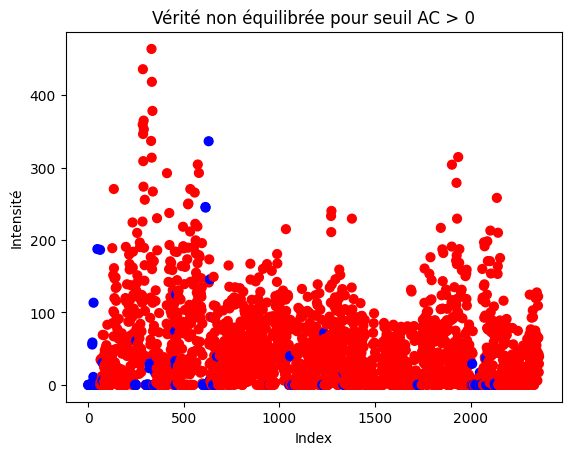

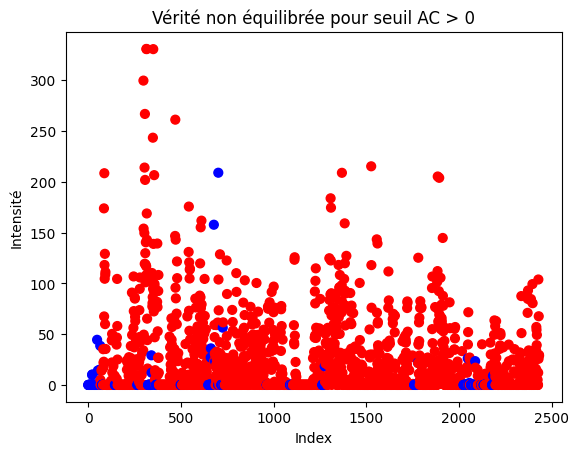

In [ ]:
lst_X_members = [X_dom, X_non_dom]
lst_Y_members = [Y_dom, Y_non_dom]
balanced_X_members = []
balanced_Y_members = []

for idx_member in range(2):
    # ********************************** Préparation des données (équilibre, suppression des None,) *****************************************************************
    # Convertir en array pour faciliter le filtrage
    X_array = np.array(lst_X_members[idx_member])
    Y_array = np.array(lst_Y_members[idx_member])
    # Créer un masque pour garder uniquement les étiquettes valides (différent de None)
    mask_None = Y_array != None
    # Appliquer le masque
    X_clean = X_array[mask_None]
    Y_clean = Y_array[mask_None]

    # Aplatir les données (mettre au bon format pour les modèles)
    X_flat = np.vstack(X_clean)  # (n_total_samples, n_features)
    Y_flat = np.hstack(Y_clean)  # (n_total_samples,)
    
    # Sans nettoyage
    #X_flat = np.vstack(X_array)  # (n_total_samples, n_features)
    #Y_flat = np.hstack(Y_array) 

    #Equilibrer en sur échantillonant la classe minoritaire. Test de : RandomOverSampler (créer des points à coté des points existants), SMOTE (créer de nouveaux points entre les points existants), ADASYN (créer de nouveaux points entre les points existants mal classifiés).

    # RandomOverSampling
    #ros = RandomOverSampler(random_state=0)
    #X_balanced, Y_balanced = ros.fit_resample(X_flat, Y_flat)

    # SMOTE
    #X_balanced, Y_balanced = SMOTE().fit_resample(X_flat, Y_flat)

    # ADASYN
    #X_balanced, Y_balanced = ADASYN().fit_resample(X_flat, Y_flat)

    # Enregistrer les valeurs
    #balanced_X_members.append(X_balanced) # balanced_X_members.append(X_flat) #
    #balanced_Y_members.append(Y_balanced) # balanced_Y_members.append(Y_flat) # 
   

    # Vérifier que les classes sont bien équilibrées
    #print(sorted(Counter(Y_balanced).items()))

    """# ------------------------------------------- Vérité --------------------------------------
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_balanced]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_balanced)), X_balanced[:, 0], c=colors, s=40)
    plt.title("Vérité équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()
    """
    # Création d'un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_flat]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)
    plt.title("Vérité non équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()


AC > 0

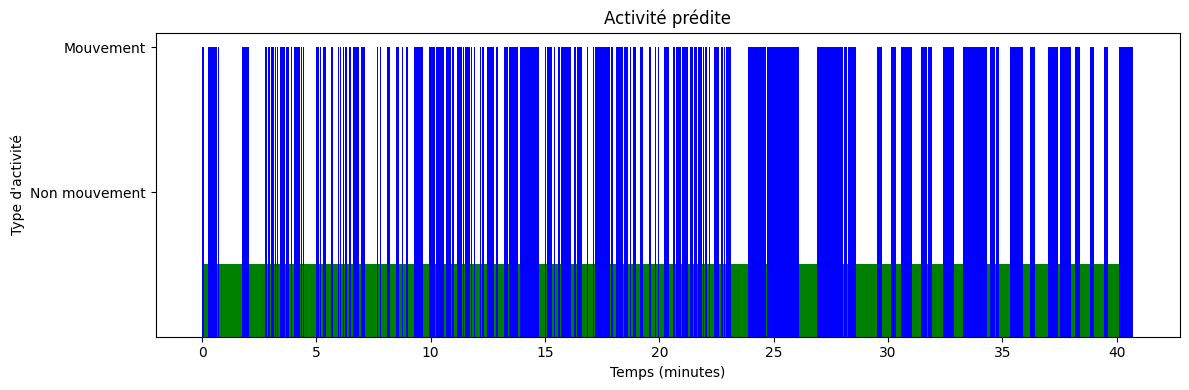

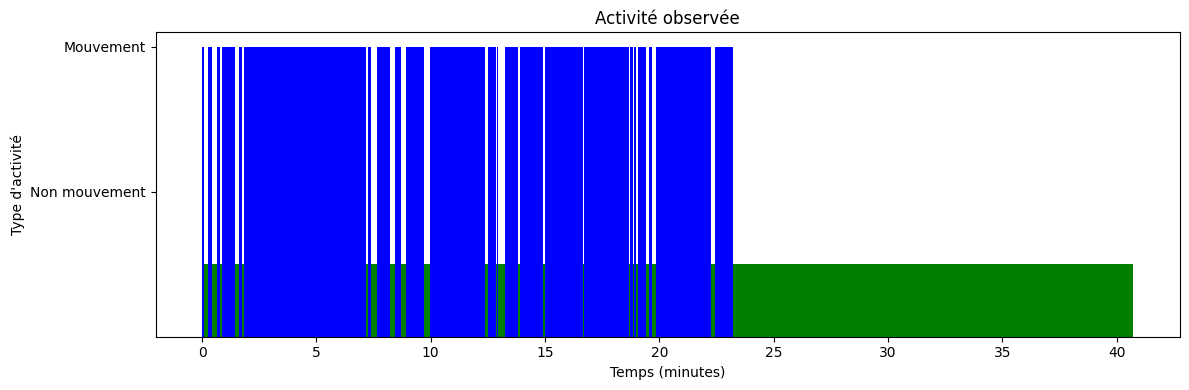

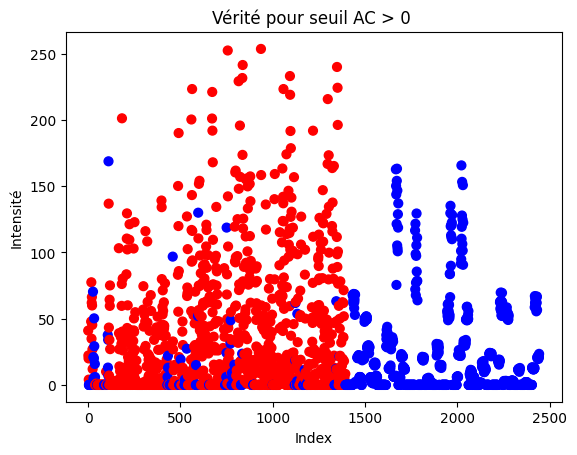

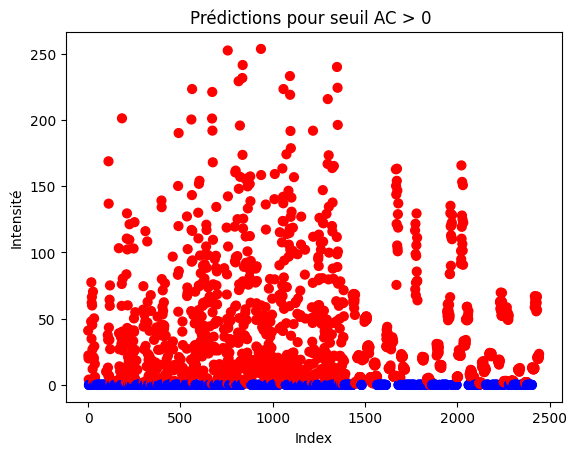

F1 score non mouvement:  0.5186775440103049
F1 score mouvement :  0.5619382571316921
Accuracy pour seuil > 0 : 0.54


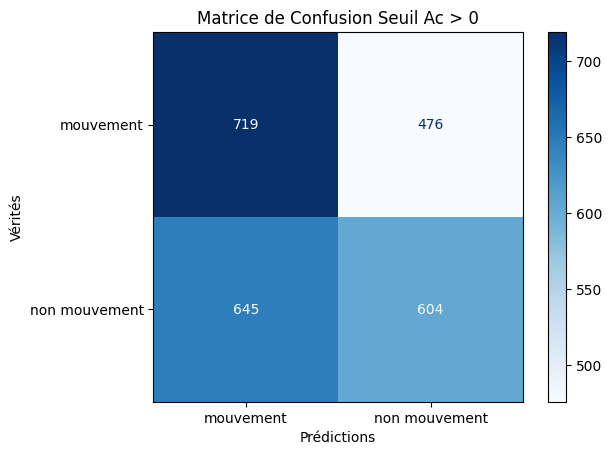

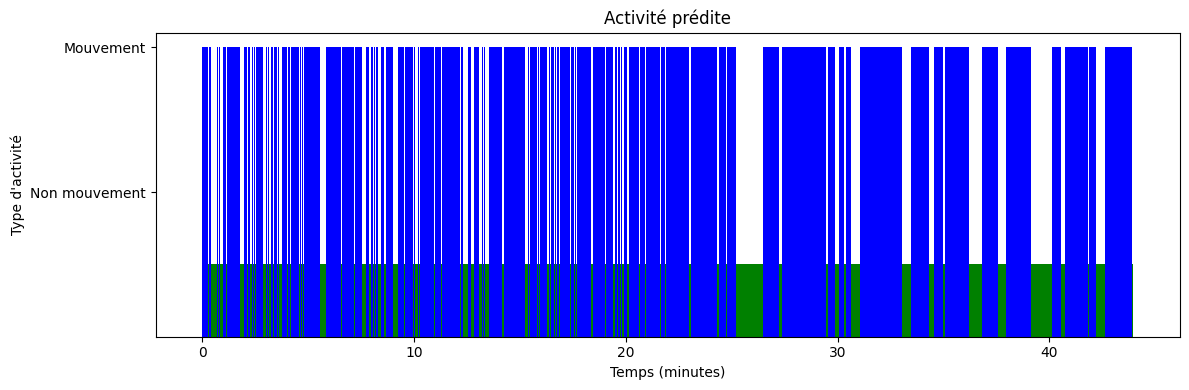

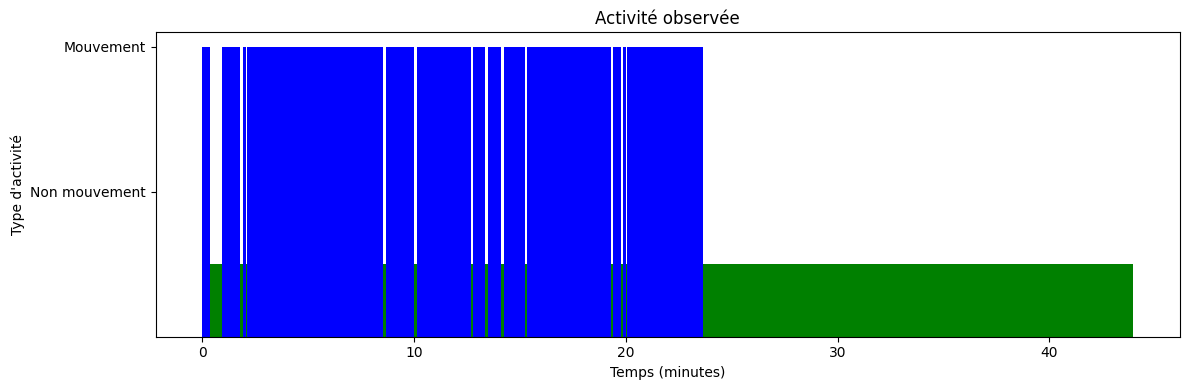

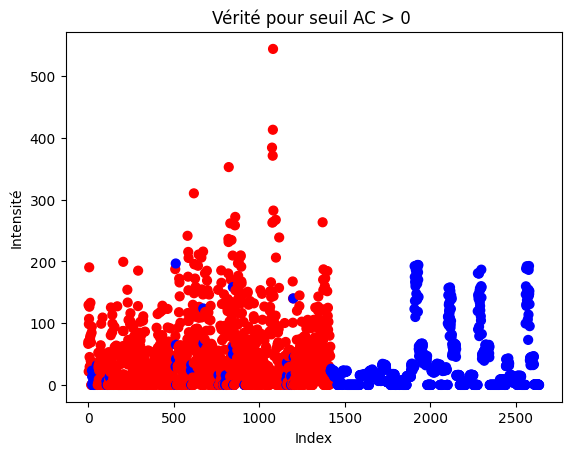

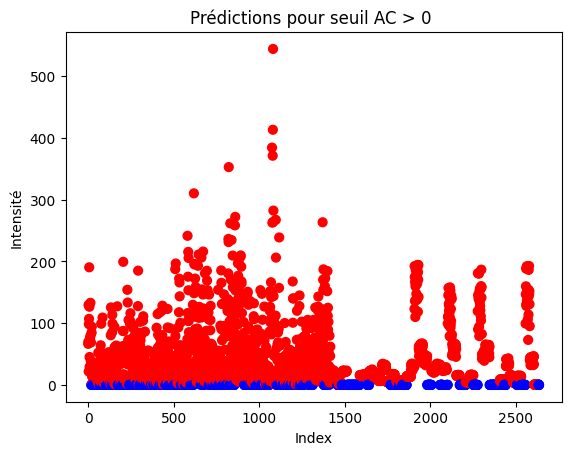

F1 score non mouvement:  0.4160475482912333
F1 score mouvement :  0.6380104390543445
Accuracy pour seuil > 0 : 0.55


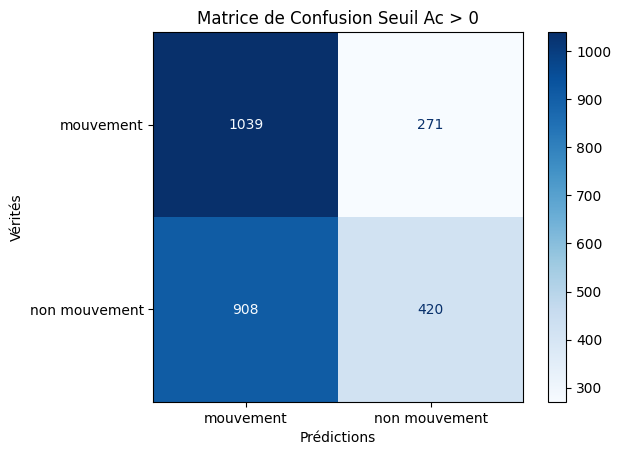

In [ ]:
for idx_members in range(2):
    #On a X_dom et Y_dom : construire un Y_pred et le comparer à Y_dom
    Y_pred_0 = []

    for idx_data in range(0,len(balanced_X_members[idx_members])):
        seuil = balanced_X_members[idx_members][idx_data]
        if seuil > 0 :
            Y_pred_0.append("mouvement")
        elif seuil == 0 :
            Y_pred_0.append("non mouvement")
        else:
            Y_pred_0.append(None)

    # -------------------------------------------- Graphique Mindmaze -------------------------------------
    x_vals = []
    heights = []
    widths = []

    for i, label in enumerate(Y_pred_0):
        if label == "mouvement":
            height = 1
        elif label == "non mouvement":
            height = 0.25
        else:
            continue  # ignore les valeurs None ou autres

        x_vals.append(i / 60) # conversion en minutes
        heights.append(height)
        widths.append(1 / 60) # largeur = 1 seconde en minutes

    # Tracé du graphique
    plt.figure(figsize=(12, 4))
    plt.bar(x_vals, heights, width=widths, color=['blue' if h == 1 else 'green' for h in heights], align='edge')

    plt.xlabel("Temps (minutes)")
    plt.ylabel("Type d'activité")
    plt.title("Activité prédite")
    plt.yticks([0.5, 1], ["Non mouvement", "Mouvement"])
    plt.tight_layout()
    plt.show()

    x_vals = []
    heights = []
    widths = []

    for i, label in enumerate(balanced_Y_members[idx_members]):
        if label == "mouvement":
            height = 1
        elif label == "non mouvement":
            height = 0.25
        else:
            continue  # ignore les valeurs None ou autres

        x_vals.append(i / 60) # conversion en minutes
        heights.append(height)
        widths.append(1 / 60) # largeur = 1 seconde en minutes

    # Tracé du graphique
    plt.figure(figsize=(12, 4))
    plt.bar(x_vals, heights, width=widths, color=['blue' if h == 1 else 'green' for h in heights], align='edge')

    plt.xlabel("Temps (minutes)")
    plt.ylabel("Type d'activité")
    plt.title("Activité observée")
    plt.yticks([0.5, 1], ["Non mouvement", "Mouvement"])
    plt.tight_layout()
    plt.show()

    
    # -------------------------------------------- Vérité -------------------------------------
    
    colors = []
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in balanced_Y_members[idx_members]]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors, s=40)
    plt.title("Vérité pour seuil AC > 0 ")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()
    # -------------------------------------------- Prédictions -------------------------------------
    colors = []
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_pred_0]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors, s=40)
    plt.title("Prédictions pour seuil AC > 0 ")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # ------------------------------------------- Evaluate the model ---------------------------------------
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_0, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_0, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score non mouvement: ", f1score_non_mouvement)
    print("F1 score mouvement : ", f1score_mouvement)

    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_members], Y_pred_0)
    print(f"Accuracy pour seuil > 0 : {accuracy:.2f}")
    cm_75 = confusion_matrix(balanced_Y_members[idx_members], Y_pred_0)

    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion Seuil Ac > 0")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    plt.show()


AC > 2

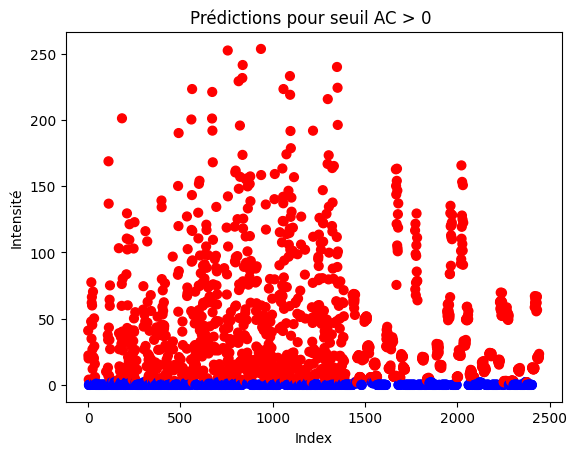

F1 score non mouvement:  0.5489063144861742
F1 score mouvement :  0.5565922920892495
Accuracy pour seuil > 0 : 0.55


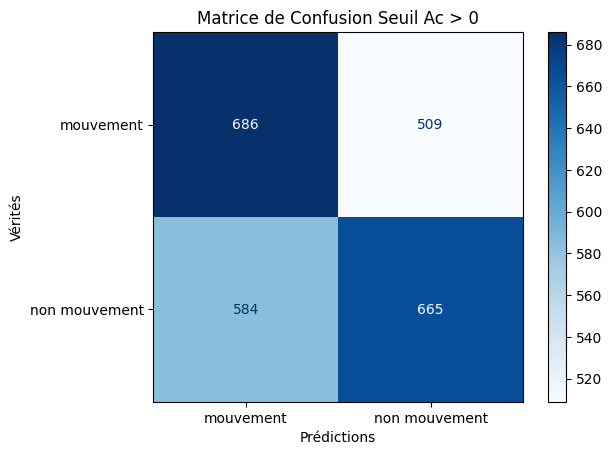

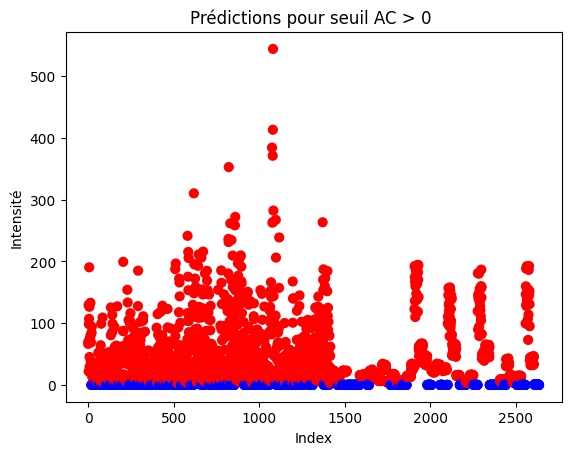

F1 score non mouvement:  0.43373493975903615
F1 score mouvement :  0.6329272102467979
Accuracy pour seuil > 0 : 0.55


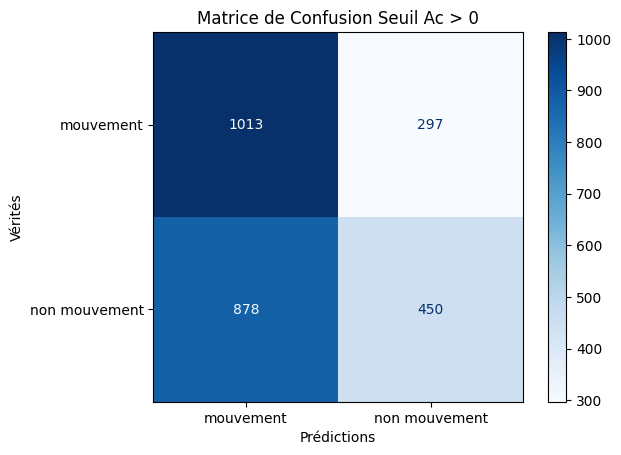

In [ ]:
for idx_members in range(2):
    #On a X_dom et Y_dom : construire un Y_pred et le comparer à Y_dom
    Y_pred_2 = []

    for idx_data in range(0,len(balanced_X_members[idx_members])):
        seuil = balanced_X_members[idx_members][idx_data]
        if seuil > 2 :
            Y_pred_2.append("mouvement")
        elif seuil <= 2 :
            Y_pred_2.append("non mouvement")
        else:
            Y_pred_2.append(None)

    # -------------------------------------------- Graphique Mindmaze -------------------------------------
    x_vals = []
    heights = []
    widths = []

    for i, label in enumerate(Y_pred_0):
        if label == "mouvement":
            height = 1
        elif label == "non mouvement":
            height = 0.25
        else:
            continue  # ignore les valeurs None ou autres

        x_vals.append(i / 60) # conversion en minutes
        heights.append(height)
        widths.append(1 / 60) # largeur = 1 seconde en minutes

    # Tracé du graphique
    plt.figure(figsize=(12, 4))
    plt.bar(x_vals, heights, width=widths, color=['blue' if h == 1 else 'green' for h in heights], align='edge')

    plt.xlabel("Temps (minutes)")
    plt.ylabel("Type d'activité")
    plt.title("Activité prédite")
    plt.yticks([0.5, 1], ["Non mouvement", "Mouvement"])
    plt.tight_layout()
    plt.show()

    x_vals = []
    heights = []
    widths = []

    for i, label in enumerate(balanced_Y_members[idx_members]):
        if label == "mouvement":
            height = 1
        elif label == "non mouvement":
            height = 0.25
        else:
            height = 0

        x_vals.append(i / 60)
        heights.append(height)
        widths.append(1 / 60)

    # Tracé du graphique
    plt.figure(figsize=(12, 4))
    plt.bar(x_vals, heights, width=widths, color=['blue' if h == 1 else 'green' for h in heights], align='edge')

    plt.xlabel("Temps (minutes)")
    plt.ylabel("Type d'activité")
    plt.title("Activité observée")
    plt.yticks([0.5, 1], ["Non mouvement", "Mouvement"])
    plt.tight_layout()
    plt.show()

    # -------------------------------------------- Prédictions -------------------------------------
    colors = []
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_pred_2]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors, s=40)
    plt.title("Prédictions pour seuil AC > 0 ")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # ------------------------------------------- Evaluate the model ---------------------------------------
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_2, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_2, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score non mouvement: ", f1score_non_mouvement)
    print("F1 score mouvement : ", f1score_mouvement)

    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_members], Y_pred_2)
    print(f"Accuracy pour seuil > 0 : {accuracy:.2f}")
    cm_75 = confusion_matrix(balanced_Y_members[idx_members], Y_pred_2)

    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion Seuil Ac > 0")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    plt.show()

Clustering

[[  9.95526157]
 [104.96057386]]


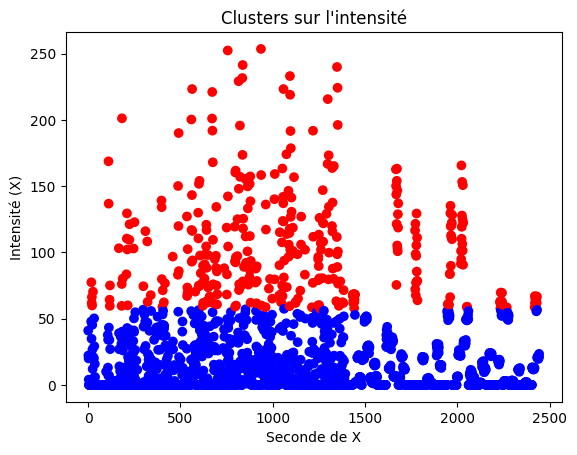

F1 score non mouvement:  0.6858340820604971
F1 score mouvement :  0.32278889606197547
Accuracy pour clustering : 0.57


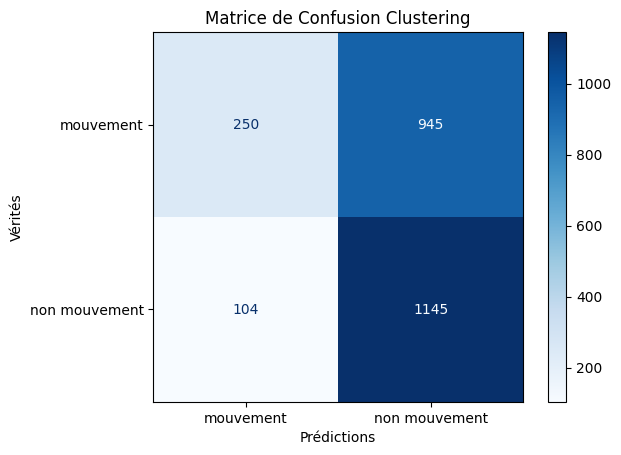

[[ 18.78501111]
 [136.60955764]]


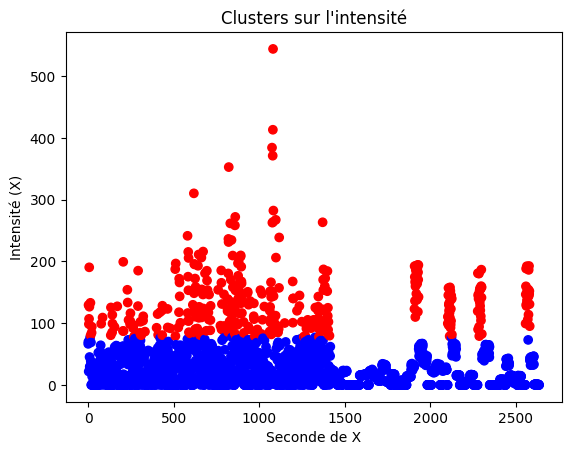

F1 score non mouvement:  0.6831986625801059
F1 score mouvement :  0.3260225251926497
Accuracy pour clustering : 0.57


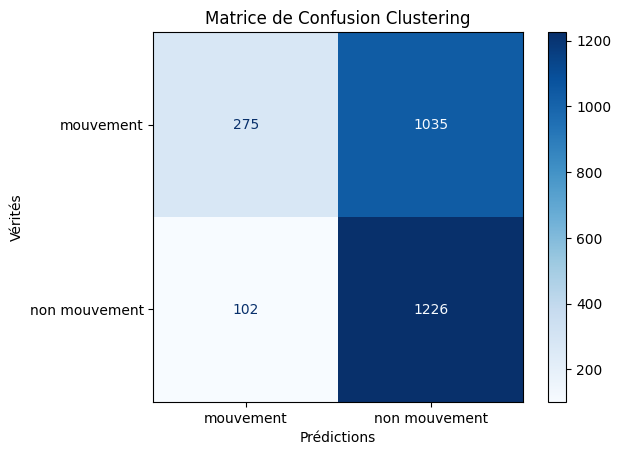

In [ ]:
#********************************* Clustering **********************************************************************************

for idx_members in range(2):
    #----------------------------------- KMEANS CLASSIQUE DONNE DE MAUVAIS RESULTATS (accuracy à 63%) ------------------------------------
    k = 2  # nombre de clusters 
    kmeans = KMeans(n_clusters=k)#
    clusters = kmeans.fit_predict(balanced_X_members[idx_members])
    centroids = np.array(kmeans.cluster_centers_)
    print(centroids)

    # Mapping pour cluster
    labels_map = ["",""]
    if centroids[1][0] > centroids[0][0]:
        labels_map[0] = 'non mouvement'
        labels_map[1] = 'mouvement'
    else:
        labels_map[0] = 'mouvement'
        labels_map[1] = 'non mouvement'

    # Traduire les clusters en classes
    predicted_labels = [labels_map[c] for c in clusters] # np.array([labels_map[c] for c in clusters])
    # Créer un mapping couleur
    color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
    # Convertir les labels en couleurs
    colors = [color_map[label] for label in predicted_labels]

    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors)
    #plt.scatter([len(X_flat)/2 ,len(X_flat)/2], [centroids[0][0], centroids[1][0]], color='black', marker='X', s=100, label='Centroids') # Affichage des centres des clusters
    plt.title("Clusters sur l'intensité")
    plt.xlabel("Seconde de X")
    plt.ylabel("Intensité (X)")
    plt.show()
    
    # ------------------------------------------- Evaluate the model ---------------------------------------
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_members], predicted_labels, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_members], predicted_labels, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score non mouvement: ", f1score_non_mouvement)
    print("F1 score mouvement : ", f1score_mouvement)

    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_members], predicted_labels)
    print(f"Accuracy pour clustering : {accuracy:.2f}")
    cm_cluster = confusion_matrix(balanced_Y_members[idx_members], predicted_labels)

    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_cluster, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion Clustering")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    plt.show()


Random Forest

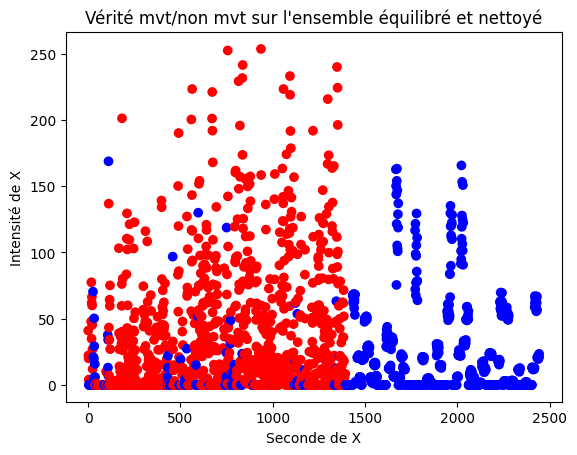

F1 score non mouvement:  0.6846153846153846
F1 score mouvement :  0.4434389140271493
Accuracy pour RF : 0.60


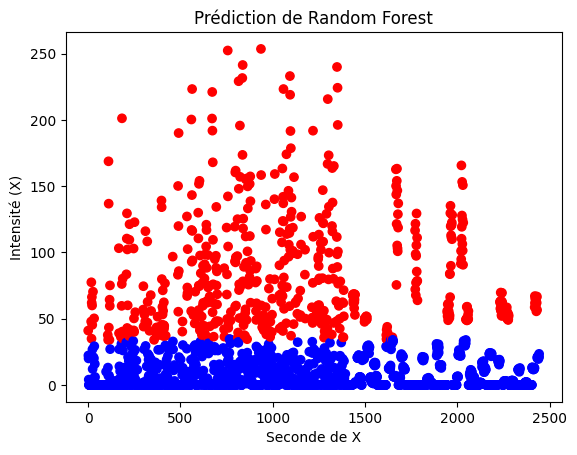

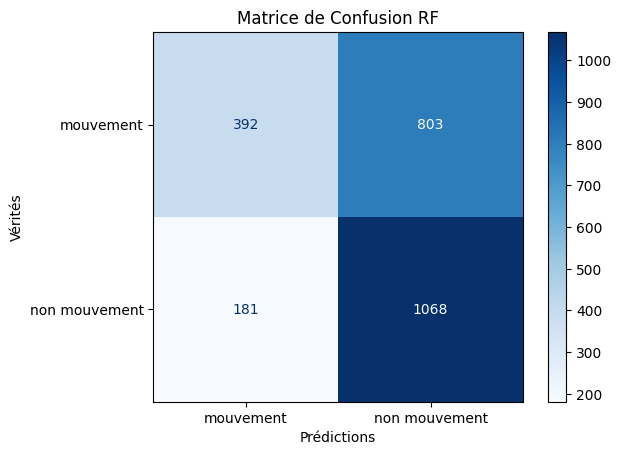

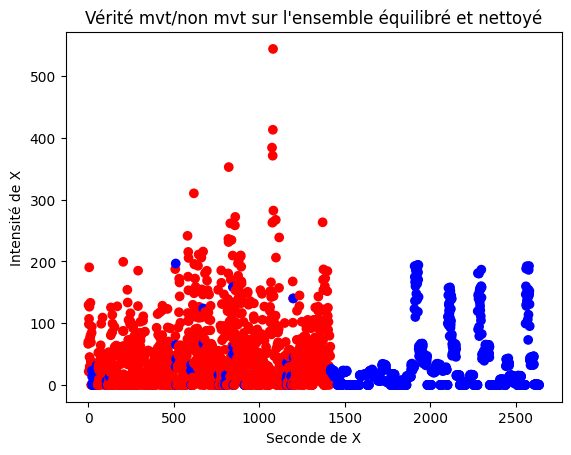

F1 score non mouvement:  0.6824769433465085
F1 score mouvement :  0.5696428571428571
Accuracy pour RF : 0.63


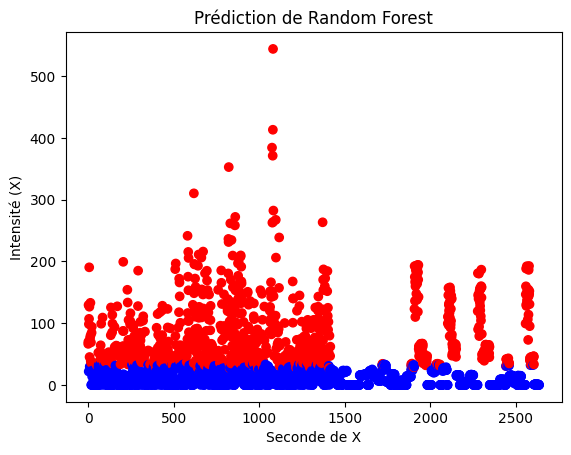

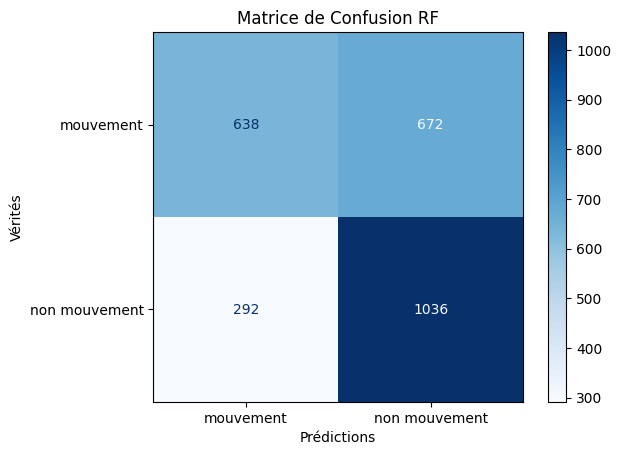

In [ ]:
for idx_members in range(2):
    #************************************** Affichage de la vérité mvt / non mvt avec les données propres ****************************************************************
    # Créer un mapping couleur différenciant mvt/ non mvt 
    color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
    # Convertir les labels en couleurs
    colors = [color_map[label] for label in balanced_Y_members[idx_members]]

    #plt.figure(figsize=(12, 4))
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors) # plt.scatter(range(len(X_flat[0:500])), X_flat[0:500], c=clusters[0:500], cmap='viridis')
    plt.title("Vérité mvt/non mvt sur l'ensemble équilibré et nettoyé")
    plt.xlabel("Seconde de X")
    plt.ylabel("Intensité de X")
    plt.show()


    # Initialize the model
    # max_depth=5, min_samples_split=5, n_estimators=200, pour data5
    Random_Forest = RandomForestClassifier(random_state=42,max_depth = 1, n_estimators=10) # Paramètres déterminés par Gridsearch et ceux là sont les meilleurs pour tous les fichiers, en non_dom 

    # Kfold definition
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Creating an array to register all the predictions (made on the different fold)
    predictions = np.empty_like(balanced_Y_members[idx_members])

    for train_idx, test_idx in kf.split(balanced_X_members[idx_members]):
        # Train the model
        Random_Forest.fit(balanced_X_members[idx_members][train_idx], balanced_Y_members[idx_members][train_idx])
        # Test the model
        y_pred = Random_Forest.predict(balanced_X_members[idx_members][test_idx])
        predictions[test_idx] = y_pred

    # ------------------------------------------- Evaluate the model ---------------------------------------
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_members], predictions, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_members], predictions, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score non mouvement: ", f1score_non_mouvement)
    print("F1 score mouvement : ", f1score_mouvement)
    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_members], predictions)
    print(f"Accuracy pour RF : {accuracy:.2f}")

    # Save the model
    #dump(Random_Forest, 'model_data_5_kfold_non_dom.joblib')

    #*************************************** Affichage de la vérité mvt / non mvt avec les données propres *****************************************************************

    # Création d'un mapping différenciant les prédictions mvt/ non mvt 
    color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
    # Convertir les labels en couleurs
    colors = [color_map[label] for label in predictions]
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors) 
    plt.title("Prédiction de Random Forest")
    plt.xlabel("Seconde de X")
    plt.ylabel("Intensité (X)")
    plt.show()

    cm_RF = confusion_matrix(balanced_Y_members[idx_members], predictions) 
    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion RF")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    plt.show()
